# Assignment 2 – Zero-Shot Image Classification with Transformers

In this assignment, you will apply a pre-trained vision–language transformer (e.g. CLIP) to perform **zero-shot** classification on the Fashion-MNIST dataset—classifying each image without any task-specific training. You will build on the concepts from Assignment 1 by comparing this “off-the-shelf” approach to the CNN you previously trained.

You will:
1. **Load** the Fashion-MNIST images using PyTorch instead of Keras.
2. **Run a zero-shot baseline** with simple text prompts to set a performance reference.
3. **Engineer improved prompts** and measure the resulting accuracy gains.
4. **Visualise image embeddings** with UMAP to inspect class separability.
5. **Conduct one mini-experiment** of your choice.
6. **Summarise findings** and reflect on strengths and weaknesses of zero-shot transformers versus a trained CNN.

# 1. Loading the Fashion-MNIST Dataset

As in assignment 1, we'll load the Fashion-MNIST dataset, but this time using `torchvision.datasets` to ensure compatibility with the `transformers` library. We will also load our model and processor from the `transformers` library.

The transformers library allows us to use pre-trained models like CLIP, which can perform zero-shot classification by leveraging the text prompts we provide. There are two key objects we will use: the `CLIPModel` for the model itself and the `CLIPProcessor` for preparing our images and text prompts.

Since we are not actually training a model in this assignment, we will set the CLIP model to evaluation mode. If the model is designed to utilize features like dropout or batch normalization, setting it to evaluation mode ensures that these features behave correctly during inference (prediction). Setting the model to evaluaton mode also tells PyTorch that we don't have to compute gradients, which can save memory and speed up inference.

In order to speed up processing, we will also move the model to an "accelerator" if available. This is typically a GPU, but modern MacBooks also have an "Apple Silicon" accelerator that can be used for inference, called MPS (Metal Performance Shaders). If you are using a MacBook with Apple Silicon, you can use the MPS device for faster processing.

In [1]:
# Uncomment and run if required
!pip3 install transformers torchvision torch accelerate

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.


In [2]:
from transformers import CLIPModel, CLIPProcessor
import torch

clip_model_name = "openai/clip-vit-base-patch32"
clip_model     = CLIPModel.from_pretrained(clip_model_name)
clip_processor = CLIPProcessor.from_pretrained(clip_model_name, use_fast=False)

# Set model to evaluation mode, as we are not training it
clip_model.eval()

# Check for accelerators
device = "cpu" # Default to CPU
if torch.cuda.is_available():
    device = "cuda" # Use GPU if available
elif torch.backends.mps.is_available():
    device = "mps"

clip_model.to(device)

print(f"Using device: {device}")

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Using device: mps


Now we are ready to load the testing set from Fashion-MNIST. We will use the `torchvision.datasets.FashionMNIST` class to load the dataset. We do not need to apply any transformations to the images, as the `CLIPProcessor` ensures any input images are in the format that the model is trained on.

You should:

- [ ] Use the `torchvision.datasets.FashionMNIST` class to load the *test* split of the dataset. Documentation is available [here](https://pytorch.org/vision/stable/generated/torchvision.datasets.FashionMNIST.html).
- [ ] Create a PyTorch `DataLoader` to iterate over the dataset in batches. Use a batch size of 16 and set `shuffle=True` to randomise the order of the images. You will also need to supply the provided `collate_clip` function to the `DataLoader collate_fn` argument to ensure the images are processed correctly. Documentation for `DataLoader` is available [here](https://pytorch.org/docs/stable/data.html#torch.utils.data.DataLoader).

In [3]:
from torchvision import datasets
from torch.utils.data import DataLoader

CLASS_NAMES = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

def collate_clip(batch):
    imgs, labels = zip(*batch) # Unzip the batch into images and labels
    proc = clip_processor(images=list(imgs),
                        return_tensors="pt",
                        padding=True) # Process images with CLIPProcessor
    # Send pixel_values to GPU/CPU now; labels stay on CPU for metrics
    return proc["pixel_values"].to(device), torch.tensor(labels)

test_dataset = datasets.FashionMNIST(
    root="./data",
    train=False,
    download=True
)
test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=True,
    collate_fn=collate_clip
)

If your code is correct, the following cell should show the first batch of images from the Fashion-MNIST dataset:

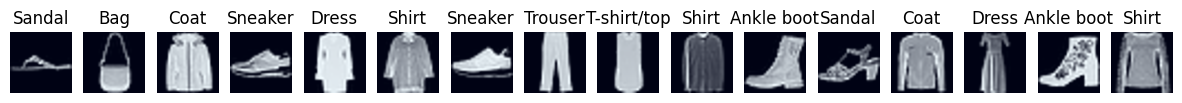

In [4]:
import matplotlib.pyplot as plt

# Display the first batch of images from `test_loader`

def show_batch(loader):
    images, labels = next(iter(loader))
    images = images.cpu()  # Move images to CPU for plotting
    # Renormalize to [0, 1] for visualization
    images = (images - images.min()) / (images.max() - images.min())
    _, axes = plt.subplots(1, len(images), figsize=(15, 5))
    for ax, img, label in zip(axes, images, labels):
        ax.imshow(img.permute(1, 2, 0))
        ax.set_title(CLASS_NAMES[label.item()])
        ax.axis('off')
    plt.show()

show_batch(test_loader)

We’re now ready to run our zero-shot classification baseline!

# Brief Introduction to Zero-Shot Classification

In Assignment 1, we followed the typical machine-learning pipeline: we trained a CNN on the Fashion-MNIST dataset, using labelled examples to update the model’s weights. While effective, that approach requires a curated, task-specific training set—a luxury you don’t always have in practice.

Zero-shot classification flips the script.  A large vision–language model (VLM) such as **CLIP** is first pre-trained on hundreds of millions of image–text pairs scraped from the web.  Because it learns *joint* visual–textual embeddings, the model can later solve new tasks simply by “measuring” how similar an image is to a **text prompt** that describes each candidate class—without seeing a single task-labelled example.

**How it works**  
1. Feed an image through CLIP’s vision encoder → **image feature**.  
2. Feed a textual prompt (e.g. “a photo of a sandal”) through CLIP’s text encoder → **text feature**.  
3. Compute cosine similarity between the image feature and every class’s text feature.  
4. Pick the class whose prompt is most similar.

For our first attempt, we’ll use the bare class names as prompts, e.g.:

- "T-shirt/top"
- "Trouser"

### You should:

- [ ] Build embeddings: use the `get_text_embeddings` helper function to create text embeddings for the class names.
- [ ] Run inference: use the `get_image_embeddings` helper function to create image embeddings.
- [ ] Compute cosine similarity: complete and use the `get_cosine_similarity` helper function to compute the cosine similarity between the image and text embeddings.
- [ ] Make predictions: use the `get_predictions` helper function to get the predicted class for each image in the batch.

Note that for normalized vectors like the ones we are using, cosine similarity is equivalent to the dot product. This means we can use the handy formula `cosine_similarity = vector_a @ vector_b.T` to compute the similarity between the image and text embeddings.

In [5]:
def get_text_embeddings(class_names: list[str]) -> torch.Tensor:
    """    Get text embeddings for the given class names using CLIP.
    Args:
        class_names (list[str]): List of class names to encode.
    Returns:
        torch.Tensor: Normalized text embeddings for the class names.
    """
    tokenized = clip_processor(text=class_names,
                               padding=True,
                               return_tensors="pt").to(device)
    
    with torch.no_grad():
        output = clip_model.get_text_features(**tokenized)
        text_embeddings = output.pooler_output if hasattr(output, "pooler_output") else output

    text_feats = text_embeddings / text_embeddings.norm(dim=-1, keepdim=True)

    return text_feats

def get_image_embeddings(images: torch.Tensor) -> torch.Tensor:
    """    Get image embeddings for the given images using CLIP.
    Args:
        images (torch.Tensor): Batch of images to encode.
    Returns:
        torch.Tensor: Normalized image embeddings for the images.
    """
    with torch.no_grad():
        output = clip_model.get_image_features(pixel_values=images)
        image_embeddings = output.pooler_output if hasattr(output, "pooler_output") else output

    image_feats = image_embeddings / image_embeddings.norm(dim=-1, keepdim=True)

    return image_feats

In [6]:
import numpy as np

def get_cosine_similarity(image_feats: torch.Tensor, text_feats: torch.Tensor) -> np.ndarray:
    """
    Compute cosine similarity between image features and text features.
    Args:
        image_feats (torch.Tensor): Image features of shape (N, D).
        text_feats (torch.Tensor): Text features of shape (M, D).
    Returns:
        numpy.ndarray: Cosine similarity matrix of shape (N, M), where N is the number of images and M is the number of text prompts.
    """
    image_feats = image_feats.cpu()  # Ensure image features are on CPU
    text_feats = text_feats.cpu()    # Ensure text features are on CPU

    # Compute cosine similarity, which is the dot product of normalized vectors
    similarity = np.dot(image_feats, text_feats.T) 
    return similarity

def get_predictions(similarity: np.ndarray) -> np.ndarray:
    """
    Get predictions based on cosine similarity scores.
    Args:
        similarity (numpy.ndarray): Cosine similarity matrix of shape (N, M), where N is the number of images and M is the number of text prompts.
    Returns:
        numpy.ndarray: Predicted class indices for each image, shape (N,).
    """
    # Get the index of the maximum similarity for each image
    return similarity.argmax(axis=1)

With these functions complete, you are ready to run the zero-shot classification baseline. Complete the code to follow these steps:

- [ ] Build text embeddings for the class names using the `get_text_embeddings` function (this only needs to be done once).
- [ ] For each batch of images:
    - [ ] Get image embeddings using the `get_image_embeddings` function.
    - [ ] Compute cosine similarity between the image and text embeddings using the `get_cosine_similarity` function.
    - [ ] Save the predictions so that we can build a confusion matrix later.
- [ ] Report the accuracy of the predictions and the confusion matrix using the `accuracy_score` and `confusion_matrix` functions from `sklearn.metrics`.

Zero-shot baseline accuracy: 62.40%


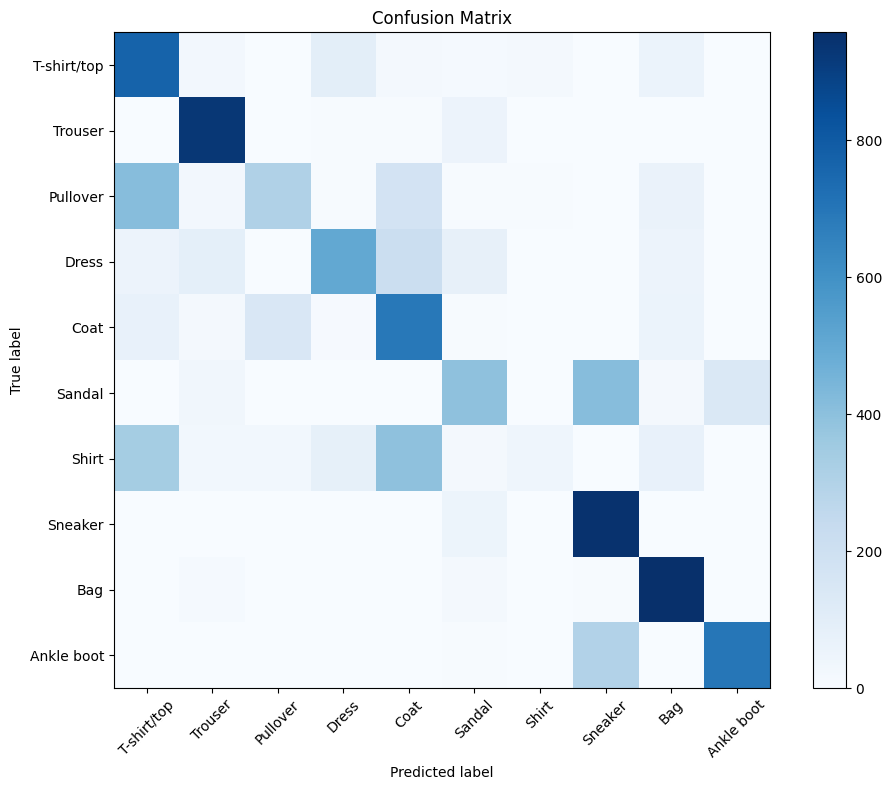

In [10]:
from sklearn.metrics import accuracy_score, confusion_matrix
# Build text embeddings once
text_embeddings = get_text_embeddings(CLASS_NAMES)

y_true, y_pred = [], []

for images, labels in test_loader:
    images = images.to(device)
    
    # Use the given function exactly
    image_embeddings = get_image_embeddings(images)
    
    # Cosine similarity (dot product because embeddings are normalized)
    similarity = image_embeddings @ text_embeddings.T
    
    # Predictions
    preds = similarity.argmax(dim=1)
    
    # Save results
    y_true.extend(labels.numpy())
    y_pred.extend(preds.cpu().numpy())

# Accuracy
accuracy = accuracy_score(y_true, y_pred)
print(f"Zero-shot baseline accuracy: {accuracy*100:.2f}%")

# Report the confusion matrix
def plot_confusion_matrix(y_true, y_pred, class_names):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title('Confusion Matrix')
    plt.colorbar()
    tick_marks = np.arange(len(class_names))
    plt.xticks(tick_marks, class_names, rotation=45)
    plt.yticks(tick_marks, class_names)
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()
    plt.show()

plot_confusion_matrix(y_true, y_pred, CLASS_NAMES)

Reflection: Consider the results. How does the performance of this zero-shot baseline compare to the CNN you trained in Assignment 1? What are the strengths and weaknesses of this approach? 

This one is performing much worse than the CNN interms of classification. The strengths are it is more flexible to add another class, no training required and maybe as it is trained on more data it should have better quality and more diverse data. The weakness is that the model is unable to capture subtle difference between images like Shirt and Tshirt and it is not trained for this specific data which is why it's accuracy is lower, unless fine tuned.

## Improving Zero-Shot Classification with Prompt Engineering

In the previous section, we directly used the class names as text prompts for zero-shot classification. However, we can often improve performance by crafting more descriptive prompts that better capture the visual characteristics of each class. For example, instead of just "T-shirt/top", we could use "a photo of a T-shirt" or "a photo of a top". This additional context can help the model make more accurate predictions.

In this section, we will experiment with more detailed prompts for each class to see if we can improve the zero-shot classification performance. You should:

- [ ] Create a list of improved prompts for each class. For example, instead of just "T-shirt/top", you could use "a photo of a T-shirt" or "a photo of a top".
- [ ] Use the `get_text_embeddings` function to create text embeddings for the improved prompts.
- [ ] Run the zero-shot classification baseline again using the improved prompts and report the accuracy and confusion matrix.

Note: Take advantage of the confusion matrix above. If two classes are often confused, consider how you might improve the prompts to help the model distinguish them better.

The aim for this section is for you to improve the performance of the model. However, if you find that the performance does not improve significantly, you can still reflect on the process and consider how you might further refine the prompts with more effort.

In [ ]:
improved_prompts = [
    "low quality photo of T-shirt top",        # T-shirt/top
    "low quality photo of trousers or long pants",       # Trouser
    "low quality photo of pullover comfy sweater",      # Pullover
    "low quality photo of dress",    # Dress
    "low quality photo of coat jacket",        # Coat
    "low quality photo of sandal open-toe shoe",    # Sandal
    "low quality photo of collar shirt formal shirt",                 # Shirt
    "low quality photo of sneaker running shoe", # Sneaker
    "low quality photo of handbag purse",            # Bag
    "low quality photo of leather ankle boot"            # Ankle boot
]

In [29]:
text_embeddings_improved = get_text_embeddings(improved_prompts)
y_true, y_pred = [], []

for images, labels in test_loader:
    images = images.to(device)
    
    # Use your provided function
    image_embeddings = get_image_embeddings(images)
    
    # Cosine similarity with improved prompts
    similarity = image_embeddings @ text_embeddings_improved.T
    
    # Predictions
    preds = similarity.argmax(dim=1)
    
    # Collect results
    y_true.extend(labels.numpy())
    y_pred.extend(preds.cpu().numpy())

# Compute accuracy
from sklearn.metrics import accuracy_score, confusion_matrix
accuracy = accuracy_score(y_true, y_pred)
print(f"Zero-shot accuracy with improved prompts: {accuracy*100:.2f}%")

Zero-shot accuracy with improved prompts: 65.24%


Reflection: How did your detailed prompts affect the zero-shot classification performance? Did you see a significant improvement compared to the baseline? What insights did you gain about the model's understanding of the classes? Do you think that with more effort you could further improve the performance? If so, how? 

Adding "low quality photo of" really improved the the performance, maybe adding black and white photo of adding more description on the image could help improve. Improved prompt performed 3% better.

## Visualizing Image Embeddings with UMAP

To better understand how the model perceives the different classes, we can visualize the image embeddings using UMAP (Uniform Manifold Approximation and Projection). UMAP is a dimensionality reduction technique that helps us see how similar or dissimilar the embeddings are in a lower-dimensional space.

By visualizing the embeddings, we can gain insights into how well the model can distinguish certain images, even without considering the text prompts. This can help us identify clusters of similar images and see if there are any overlaps between classes.

You should:

- [ ] Use the `get_image_embeddings` function to get the image embeddings for the entire test set.
- [ ] Use UMAP to reduce the dimensionality of the image embeddings to 2D.
- [ ] Plot the 2D embeddings, coloring each point by its true class label.

You may need to install the `umap-learn` library if you haven't already. You can do this by running `pip install umap-learn`.

In [23]:
# Uncomment the following line to install UMAP if you haven't already
!pip3 install umap-learn

Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 90 kB 5.9 MB/s eta 0:00:011
     |████████████████████████████████| 73 kB 4.2 MB/s  eta 0:00:01
     |████████████████████████████████| 2.7 MB 47.5 MB/s eta 0:00:01
     |████████████████████████████████| 30.3 MB 28.3 MB/s eta 0:00:01
     |████████████████████████████████| 11.1 MB 28.8 MB/s eta 0:00:01
     |████████████████████████████████| 28.8 MB 21.5 MB/s eta 0:00:01
     |████████████████████████████████| 309 kB 40.8 MB/s eta 0:00:01
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.


Embeddings shape: (10000, 512)
Labels shape: (10000,)


/Users/chhaganimahima/Desktop/dsi_assignments/deep_learning/deep-learning-env/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/chhaganimahima/Desktop/dsi_assignments/deep_learning/deep-learning-env/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP 2D shape: (10000, 2)


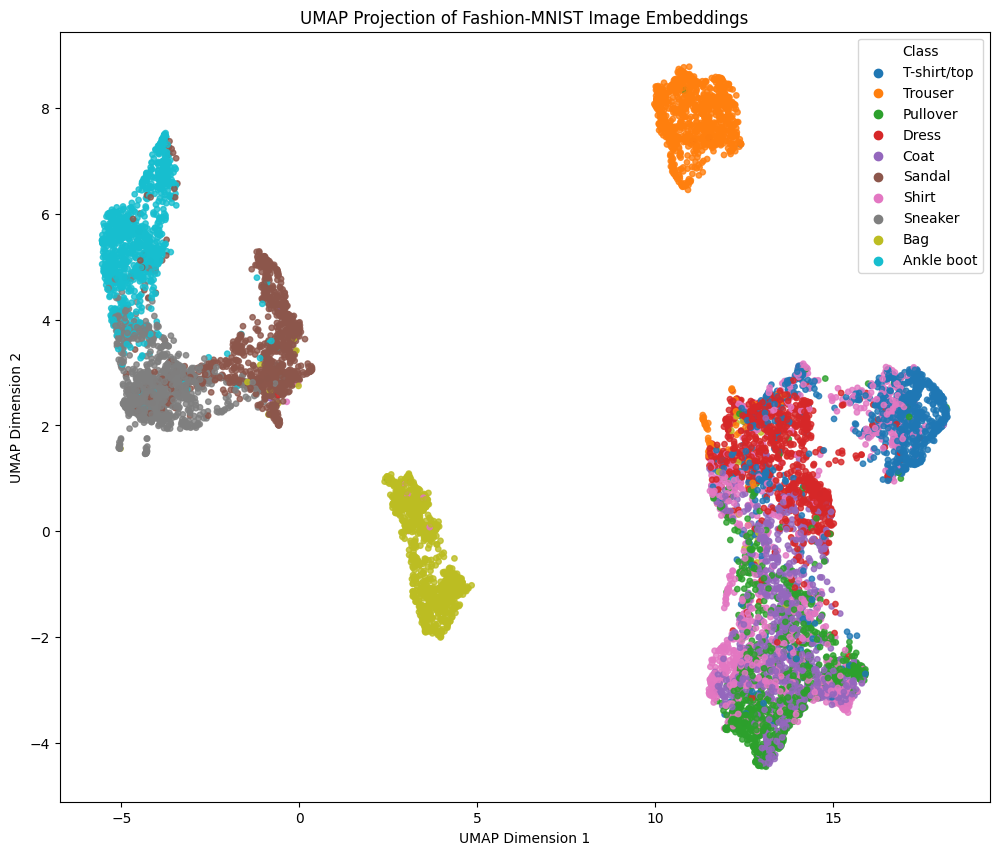

In [30]:
from umap import UMAP

# ------------------------------------------------------------
# 1. Collect image embeddings
# ------------------------------------------------------------
all_img_emb = []
all_labels  = []

for pixel_values, labels in test_loader:
    ixel_values = pixel_values.to(device)
    
    image_embeddings = get_image_embeddings(pixel_values)
    
    all_img_emb.append(image_embeddings.cpu().numpy())
    all_labels.append(labels.numpy())

# Stack into single arrays
all_img_emb = np.vstack(all_img_emb)  # shape: (num_images, embedding_dim)
all_labels  = np.hstack(all_labels)   # shape: (num_images,)

print("Embeddings shape:", all_img_emb.shape)
print("Labels shape:", all_labels.shape)

# ------------------------------------------------------------
# 2. Fit UMAP
# ------------------------------------------------------------
umap_reducer = UMAP(n_components=2, random_state=42)
embeddings_2d = umap_reducer.fit_transform(all_img_emb)

print("UMAP 2D shape:", embeddings_2d.shape)

# ------------------------------------------------------------
# 3. Plot coloured by ground-truth label
# ------------------------------------------------------------
plt.figure(figsize=(12, 10))

# Use a colormap for 10 classes
colors = plt.cm.tab10(all_labels / 9)  # normalize label indices for colormap

plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1],
            c=colors, s=15, alpha=0.8)

# Add legend for classes
for i, class_name in enumerate(CLASS_NAMES):
    plt.scatter([], [], color=plt.cm.tab10(i / 9), label=class_name)
plt.legend(title="Class")
plt.title("UMAP Projection of Fashion-MNIST Image Embeddings")
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.show()

The UMAP embeddings allow us to see how separable or non-separable different classes are with our specific model. If two specific images are very similar, then they will be placed near each other on this graph. 

Reflection: Do you notice any challenges in distinguishing images based on this figure? Are there any types of clothing in the dataset which the model has no trouble distinguishing from the others?

The challenges here are that shirt coat and pullover points overlap each other a lot making them hard to distinguish. WHile trouser and bags can be predicted easily.

## Mini-Experiment

In this section, you will conduct a mini-experiment of your choice to further explore the capabilities of zero-shot classification with transformers. This can be anything you'd like, but here are some ideas to get you started.

### A. Alternative Model

So far we have been utilizing OpenAI's CLIP model for zero-shot classification. However, there are many other vision–language models available in the `transformers` library that you can experiment with. For example, there are larger CLIP models such as [clip-vit-large-patch14](https://huggingface.co/openai/clip-vit-large-patch14), and open-source versions such as [laion/CLIP-ViT-B-32-laion2B-s34B-b79K](https://huggingface.co/laion/CLIP-ViT-B-32-laion2B-s34B-b79K). You can also search huggingface [here](https://huggingface.co/models?sort=trending&search=clip) to find other models that might be suitable for zero-shot classification.

You can try using a different model to see if it improves the zero-shot classification performance. You should:
- [ ] Load a different model and processor from the `transformers` library.
- [ ] Run the zero-shot classification baseline with the new model and report the accuracy and confusion matrix.
- [ ] Reflect on the performance of the new model compared to the original CLIP model
  - How does the new model perform compared to the original CLIP model?
  - Do you notice any differences in the types of errors made by the new model?

### B. Multiple-Description Classification

Another interesting experiment is to explore multiple-description classification. *This involves providing multiple text prompts for each class, allowing the model to choose the most relevant one. For example, instead of just "T-shirt/top", you could provide "a photo of a T-shirt", "a photo of a top", and "a photo of a shirt". This can help the model better understand the class and increases the likelihood of a correct prediction. You should:

- [ ] Create a list of multiple prompts for each class.
- [ ] Use the `get_text_embeddings` function to create text embeddings for the multiple prompts.
- [ ] Run the zero-shot classification baseline again using the multiple prompts and report the accuracy and confusion matrix.
- [ ] Consider the model to be correct if it guesses *any* of the prompts belonging to the correct class.

### C. Top-K Classification

In some classification tasks, it can be useful to consider if the right answer is among the top K (e.g. top 3) predictions. This can be particularly useful in cases where the model is uncertain or when there are multiple similar classes. You should:

- [ ] Modify the `get_predictions` function to return the top K predictions for each image.
- [ ] Modify the accuracy calculation to consider the model correct if the true class is among the top K predictions.
- [ ] Report the accuracy and confusion matrix for the top K predictions. Report at least two different values of K (e.g. K=2 and K=4).

### D. Other Ideas

You are welcome to come up with your own mini-experiment! Explain your idea in the report and implement it. Did it work as you expected? What did you learn from it?

In [31]:
def get_topk_predictions(similarity: np.ndarray, k: int = 1) -> np.ndarray:
    """
    Return top-k predicted class indices for each image.
    
    Args:
        similarity (np.ndarray): shape (N, M)
        k (int): number of top predictions
    
    Returns:
        np.ndarray: shape (N, k)
    """
    # argsort in descending order
    return np.argsort(-similarity, axis=1)[:, :k]

In [32]:
def topk_accuracy(y_true: np.ndarray, topk_preds: np.ndarray) -> float:
    """
    Compute top-k accuracy.
    
    y_true: shape (N,)
    topk_preds: shape (N, k)
    """
    correct = 0
    for i in range(len(y_true)):
        if y_true[i] in topk_preds[i]:
            correct += 1
    return correct / len(y_true)

In [33]:
from sklearn.metrics import confusion_matrix

text_embeddings = get_text_embeddings(CLASS_NAMES)

y_true = []
all_similarity = []

for images, labels in test_loader:
    images = images.to(device)
    
    image_embeddings = get_image_embeddings(images)
    similarity = get_cosine_similarity(image_embeddings, text_embeddings)
    
    all_similarity.append(similarity)
    y_true.extend(labels.numpy())

all_similarity = np.vstack(all_similarity)
y_true = np.array(y_true)

# Top-1 (normal accuracy)
top1_preds = get_topk_predictions(all_similarity, k=1)
top1_acc = topk_accuracy(y_true, top1_preds)

# Top-2
top2_preds = get_topk_predictions(all_similarity, k=2)
top2_acc = topk_accuracy(y_true, top2_preds)

# Top-4
top4_preds = get_topk_predictions(all_similarity, k=4)
top4_acc = topk_accuracy(y_true, top4_preds)

print("Top-1 Accuracy:", top1_acc)
print("Top-2 Accuracy:", top2_acc)
print("Top-4 Accuracy:", top4_acc)

/var/folders/kw/nbscy10d6cxc9l7xgcj8wxv80000gn/T/ipykernel_94325/849755481.py:16: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  similarity = np.dot(image_feats, text_feats.T)


Top-1 Accuracy: 0.624
Top-2 Accuracy: 0.8146
Top-4 Accuracy: 0.9245


### Short Report

In this section, you will write a short report summarizing your findings from the mini-experiment. The report should include the following sections:

- **Introduction**: Briefly describe the mini-experiment you conducted and its objectives.
- **Methodology**: Explain the steps you took to conduct the experiment, including any modifications you made to the code or model.
- **Results**: Present the results of your experiment.
- **Discussion**: Reflect on the performance of the model and the implications of your findings. Consider the strengths and weaknesses of zero-shot transformers versus a trained CNN.

### Introduction
In this mini-experiment, I investigated the effect of Top-K classification on zero-shot performance using a pre-trained CLIP model. Instead of evaluating the model solely on Top-1 accuracy (where only the highest-scoring prediction is considered), I explored whether the correct class appears among the top K most similar text prompts.

The objective was to determine whether zero-shot CLIP makes completely incorrect predictions, or whether it often ranks the correct class highly but not first. This provides insight into the model’s confidence and ranking quality.

### Methodology
The experiment followed the same zero-shot pipeline used in the baseline:

1. Image embeddings were generated using the get_image_embeddings function.
2. Text embeddings were generated using get_text_embeddings for the Fashion-MNIST class names.
3. Cosine similarity was computed between each image embedding and all class text embeddings.
4. Instead of selecting only the maximum similarity score (Top-1), I modified the evaluation to return the top K most similar classes using sorting.
5. A prediction was considered correct if the true class label appeared among the top K predictions.

I evaluated the model using:

- Top-1 accuracy
- Top-2 accuracy
- Top-4 accuracy

No retraining or additional forward passes were performed — only the evaluation metric was changed.

### Results
The results were as follows:

Top-1 Accuracy: 62.4%

Top-2 Accuracy: 81.46%

Top-4 Accuracy: 92.45%

While the Top-1 accuracy was moderate, there was a substantial increase when allowing multiple guesses. The jump from 62.4% to 81.46% when moving from Top-1 to Top-2 is particularly significant, showing us that the model is almost always close to the correct answer.

### Discussion
The Top-K experiment reveals important insights about the behavior of zero-shot transformers.

First, the large increase from Top-1 to Top-2 accuracy (+19%) suggests that many errors are near-misses. The correct class is frequently ranked second rather than first. This indicates that CLIP’s embedding space captures meaningful semantic relationships between clothing categories.

Second, the Top-4 accuracy of 92.45% demonstrates that the correct class is almost always among the model’s highest-ranked predictions. This suggests that the model has learned a strong internal representation of visual similarity, even though it was not trained specifically on Fashion-MNIST.

Compared to the CNN trained in Assignment 1, the zero-shot CLIP model likely achieved lower Top-1 accuracy. However, the CNN required supervised training on labeled data, while CLIP required no additional training at all. This highlights a key trade-off:

- CNN: Higher task-specific accuracy but requires labeled data and training time.
- Zero-shot CLIP: Lower Top-1 accuracy but strong generalization without any task-specific training.

Strengths of the zero-shot approach include flexibility, no training requirement, and strong semantic ranking ability. Weaknesses include difficulty distinguishing visually similar classes such as shirts, pullovers, and coats.

Overall, this experiment shows that while zero-shot transformers may not outperform specialized models in strict accuracy, they possess powerful ranking capabilities and impressive generalization ability.

🚨 **Please review our [Assignment Submission Guide](https://github.com/UofT-DSI/onboarding/blob/main/onboarding_documents/submissions.md)** 🚨 for detailed instructions on how to format, branch, and submit your work. Following these guidelines is crucial for your submissions to be evaluated correctly.
### Submission Parameters:
* Submission Due Date: `23:59 PM - 02/11/2025`
* The branch name for your repo should be: `assignment-2`
* What to submit for this assignment:
    * This Jupyter Notebook (assignment_2.ipynb)
    * The Lab 4 notebook (labs/lab_4.ipynb)
    * The Lab 5 notebook (labs/lab_5.ipynb)
    * The Lab 6 notebook (labs/lab_6.ipynb)
* What the pull request link should look like for this assignment: `https://github.com/<your_github_username>/deep_learning/pull/<pr_id>`
* Open a private window in your browser. Copy and paste the link to your pull request into the address bar. Make sure you can see your pull request properly. This helps the technical facilitator and learning support staff review your submission easily.
Checklist:
- [ ] Created a branch with the correct naming convention.
- [ ] Ensured that the repository is public.
- [ ] Reviewed the PR description guidelines and adhered to them.
- [ ] Verify that the link is accessible in a private browser window.
If you encounter any difficulties or have questions, please don't hesitate to reach out to our team via our Slack at `#cohort-7-help-ml`. Our Technical Facilitators and Learning Support staff are here to help you navigate any challenges.